Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Image resized to 512×512
Loading SD 2.1 components from sd2-community/stable-diffusion-2-1 …


Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: sd2-community/stable-diffusion-2-1
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The config attributes {'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


SD 2.1 loaded ✓

[1/3] Generating DiffEdit semantic mask …
    Mask shape: (1, 64, 64)  |  nonzero ratio: 17.16%

[2/3] DDIM-inverting input image …
    Inverted latents shape: torch.Size([1, 40, 4, 64, 64])
SD2.1 offloaded to CPU ✓

[3/3] Running SDXL inpainting …
Loading SDXL inpainting pipeline from diffusers/stable-diffusion-xl-1.0-inpainting-0.1 …


...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1/snapshots/115134f363124c53c7d878647567d04daf26e41e/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


SDXL inpainting loaded ✓


  0%|          | 0/40 [00:00<?, ?it/s]


Done ✓


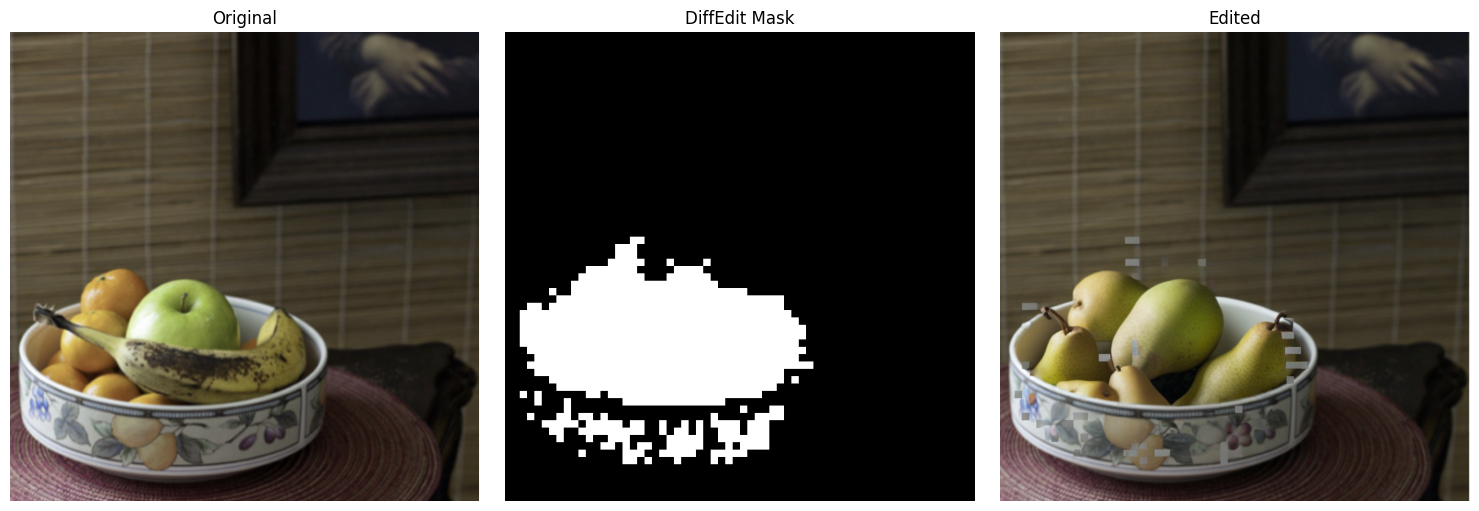

Saved → diffedit_result.png


In [1]:
# =============================================================================
# DiffEdit — Standalone Kaggle T4 Implementation
# Paper: "DiffEdit: Diffusion-based semantic image editing with mask guidance"
#
# Pipeline:
#   Step 1 – generate_mask()  : SD 2.1  → semantic mask via noise diff
#   Step 2 – invert()         : SD 2.1  → DDIM inversion of input image
#   Step 3 – __call__()       : SDXL inpainting → guided image edit
# =============================================================================

# ── 0. Install / imports ──────────────────────────────────────────────────────
# Run this cell first (Kaggle already has most of these)
# !pip install -q diffusers transformers accelerate

import inspect
import warnings
from dataclasses import dataclass
from typing import Any, Callable, List, Optional, Union

import numpy as np
import PIL.Image
import torch
import torch.nn.functional as F
from diffusers import (
    AutoencoderKL,
    DDIMInverseScheduler,
    DDIMScheduler,
    StableDiffusionXLInpaintPipeline,
    UNet2DConditionModel,
)
from diffusers.image_processor import VaeImageProcessor
from diffusers.utils import logging
from diffusers.utils.torch_utils import randn_tensor
from transformers import CLIPImageProcessor, CLIPTextModel, CLIPTokenizer

warnings.filterwarnings("ignore")
logger = logging.get_logger(__name__)

# ── 1. Model IDs ─────────────────────────────────────────────────────────────
SD_MODEL   = "sd2-community/stable-diffusion-2-1"          # mask + inversion
SDXL_MODEL = "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"  # final edit

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16   # T4 works well with fp16

# =============================================================================
# ── 2. Helper functions (from original pipeline file) ────────────────────────
# =============================================================================

def auto_corr_loss(hidden_states, generator=None):
    reg_loss = 0.0
    for i in range(hidden_states.shape[0]):
        for j in range(hidden_states.shape[1]):
            noise = hidden_states[i : i + 1, j : j + 1, :, :]
            while True:
                roll_amount = torch.randint(
                    noise.shape[2] // 2, (1,), generator=generator
                ).item()
                reg_loss += (noise * torch.roll(noise, shifts=roll_amount, dims=2)).mean() ** 2
                reg_loss += (noise * torch.roll(noise, shifts=roll_amount, dims=3)).mean() ** 2
                if noise.shape[2] <= 8:
                    break
                noise = F.avg_pool2d(noise, kernel_size=2)
    return reg_loss


def kl_divergence(hidden_states):
    return (
        hidden_states.var()
        + hidden_states.mean() ** 2
        - 1
        - torch.log(hidden_states.var() + 1e-7)
    )


def preprocess_mask(mask, batch_size: int = 1):
    """Convert various mask formats to a normalised [0,1] float tensor."""
    if not isinstance(mask, torch.Tensor):
        if isinstance(mask, (PIL.Image.Image, np.ndarray)):
            mask = [mask]
        if isinstance(mask, list):
            if isinstance(mask[0], PIL.Image.Image):
                mask = [np.array(m.convert("L")).astype(np.float32) / 255.0 for m in mask]
            if isinstance(mask[0], np.ndarray):
                mask = (
                    np.stack(mask, axis=0)
                    if mask[0].ndim < 3
                    else np.concatenate(mask, axis=0)
                )
                mask = torch.from_numpy(mask)
            elif isinstance(mask[0], torch.Tensor):
                mask = (
                    torch.stack(mask, dim=0)
                    if mask[0].ndim < 3
                    else torch.cat(mask, dim=0)
                )

    if mask.ndim == 2:
        mask = mask.unsqueeze(0).unsqueeze(0)
    if mask.ndim == 3:
        mask = mask.unsqueeze(0) if mask.shape[0] == 1 else mask.unsqueeze(1)

    if batch_size > 1:
        if mask.shape[0] == 1:
            mask = torch.cat([mask] * batch_size)
        elif mask.shape[0] != batch_size:
            raise ValueError(
                f"`mask_image` batch size {mask.shape[0]} cannot be broadcast to {batch_size}"
            )

    if mask.shape[1] != 1:
        raise ValueError(f"`mask_image` must have 1 channel, got {mask.shape[1]}")
    if mask.min() < 0 or mask.max() > 1:
        raise ValueError("`mask_image` should be in [0, 1] range")

    mask[mask < 0.5] = 0
    mask[mask >= 0.5] = 1
    return mask


# =============================================================================
# ── 3. SD2.1 mask-generation + DDIM-inversion class ─────────────────────────
# =============================================================================

class DiffEditSD21:
    """
    Wraps SD 2.1 to provide:
      • generate_mask()  – DiffEdit semantic mask
      • invert()         – DDIM latent inversion
    """

    def __init__(self, model_id: str = SD_MODEL, device=DEVICE, dtype=DTYPE):
        self.device = device
        self.dtype  = dtype

        print(f"Loading SD 2.1 components from {model_id} …")
        self.tokenizer    = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
        self.text_encoder = CLIPTextModel.from_pretrained(
            model_id, subfolder="text_encoder", torch_dtype=dtype
        ).to(device)
        self.vae = AutoencoderKL.from_pretrained(
            model_id, subfolder="vae", torch_dtype=dtype
        ).to(device)
        self.unet = UNet2DConditionModel.from_pretrained(
            model_id, subfolder="unet", torch_dtype=dtype
        ).to(device)

        # Forward DDIM scheduler
        self.scheduler = DDIMScheduler.from_pretrained(model_id, subfolder="scheduler")
        # Inverse DDIM scheduler
        self.inverse_scheduler = DDIMInverseScheduler.from_pretrained(
            model_id, subfolder="scheduler"
        )

        self.vae_scale_factor = 2 ** (len(self.vae.config.block_out_channels) - 1)
        self.image_processor  = VaeImageProcessor(vae_scale_factor=self.vae_scale_factor)

        self.text_encoder.eval()
        self.vae.eval()
        self.unet.eval()
        print("SD 2.1 loaded ✓")

    # ── internal helpers ──────────────────────────────────────────────────────

    def _encode_prompt(
        self,
        prompt,
        num_images_per_prompt: int = 1,
        do_cfg: bool = True,
        negative_prompt=None,
    ):
        """Returns (uncond_embeds, cond_embeds) each on self.device."""
        if isinstance(prompt, str):
            prompt = [prompt]
        batch_size = len(prompt)

        text_inputs = self.tokenizer(
            prompt,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad():
            cond_embeds = self.text_encoder(
                text_inputs.input_ids.to(self.device)
            )[0]

        # repeat for num_images_per_prompt
        bs, seq_len, _ = cond_embeds.shape
        cond_embeds = cond_embeds.repeat(1, num_images_per_prompt, 1)
        cond_embeds = cond_embeds.view(bs * num_images_per_prompt, seq_len, -1)

        if not do_cfg:
            return cond_embeds

        # unconditional
        if negative_prompt is None:
            uncond_tokens = [""] * batch_size
        elif isinstance(negative_prompt, str):
            uncond_tokens = [negative_prompt] * batch_size
        else:
            uncond_tokens = negative_prompt

        uncond_inputs = self.tokenizer(
            uncond_tokens,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad():
            uncond_embeds = self.text_encoder(
                uncond_inputs.input_ids.to(self.device)
            )[0]

        uncond_embeds = uncond_embeds.repeat(1, num_images_per_prompt, 1)
        uncond_embeds = uncond_embeds.view(bs * num_images_per_prompt, seq_len, -1)

        return uncond_embeds, cond_embeds

    def _encode_image(self, image, generator=None):
        """PIL image → VAE latent tensor."""
        pixel = self.image_processor.preprocess(image).to(self.device, self.dtype)
        with torch.no_grad():
            latent = self.vae.encode(pixel).latent_dist.sample(generator)
        return self.vae.config.scaling_factor * latent

    def _get_timesteps(self, num_steps, strength):
        init_timestep = min(int(num_steps * strength), num_steps)
        t_start = max(num_steps - init_timestep, 0)
        return self.scheduler.timesteps[t_start * self.scheduler.order :], num_steps - t_start

    def _get_inverse_timesteps(self, num_steps, strength):
        init_timestep = min(int(num_steps * strength), num_steps)
        t_start = max(num_steps - init_timestep, 0)
        if t_start == 0:
            return self.inverse_scheduler.timesteps, num_steps
        return self.inverse_scheduler.timesteps[:-t_start], num_steps - t_start

    def _get_epsilon(self, model_output, sample, timestep):
        pred_type = self.inverse_scheduler.config.prediction_type
        alpha = self.inverse_scheduler.alphas_cumprod[timestep]
        beta  = 1 - alpha
        if pred_type == "epsilon":
            return model_output
        elif pred_type == "sample":
            return (sample - alpha**0.5 * model_output) / beta**0.5
        elif pred_type == "v_prediction":
            return alpha**0.5 * model_output + beta**0.5 * sample
        raise ValueError(f"Unknown prediction_type: {pred_type}")

    # ── public API ────────────────────────────────────────────────────────────

    @torch.no_grad()
    def generate_mask(
        self,
        image: PIL.Image.Image,
        source_prompt: str,
        target_prompt: str,
        num_maps_per_mask: int = 10,
        mask_encode_strength: float = 0.5,
        mask_thresholding_ratio: float = 3.0,
        num_inference_steps: int = 50,
        guidance_scale: float = 7.5,
        generator: Optional[torch.Generator] = None,
    ) -> np.ndarray:
        """
        Generate a binary semantic mask that highlights the region to edit.

        Returns
        -------
        np.ndarray  shape (1, H//8, W//8)  values in {0, 1}
        """
        do_cfg = guidance_scale > 1.0

        # Encode source & target prompts (repeated for num_maps_per_mask)
        src_uncond, src_cond = self._encode_prompt(
            source_prompt, num_images_per_prompt=num_maps_per_mask, do_cfg=True
        )
        tgt_uncond, tgt_cond = self._encode_prompt(
            target_prompt, num_images_per_prompt=num_maps_per_mask, do_cfg=True
        )

        if do_cfg:
            # order: [src_uncond, src_cond, tgt_uncond, tgt_cond]
            prompt_embeds = torch.cat([src_uncond, src_cond, tgt_uncond, tgt_cond])
        else:
            prompt_embeds = torch.cat([src_cond, tgt_cond])

        # Preprocess & repeat image
        pixel = self.image_processor.preprocess(image)
        pixel = pixel.repeat_interleave(num_maps_per_mask, dim=0).to(self.device, self.dtype)

        # Set timesteps and pick encode timestep
        self.scheduler.set_timesteps(num_inference_steps, device=self.device)
        timesteps, _ = self._get_timesteps(num_inference_steps, mask_encode_strength)
        encode_t = timesteps[0]

        # Encode image to latents and add noise
        with torch.no_grad():
            latents = self.vae.encode(pixel).latent_dist.sample(generator)
        latents = self.vae.config.scaling_factor * latents
        noise = randn_tensor(latents.shape, generator=generator, device=self.device, dtype=self.dtype)
        noisy_latents = self.scheduler.add_noise(latents, noise, encode_t)

        # Stack for CFG (4x or 2x)
        factor = 4 if do_cfg else 2
        model_input = torch.cat([noisy_latents] * factor)
        model_input = self.scheduler.scale_model_input(model_input, encode_t)

        # Single UNet forward pass
        noise_pred = self.unet(
            model_input, encode_t, encoder_hidden_states=prompt_embeds
        ).sample

        if do_cfg:
            # chunks: src_uncond_pred, src_cond_pred, tgt_uncond_pred, tgt_cond_pred
            neg_src, pos_src, neg_tgt, pos_tgt = noise_pred.chunk(4)
            noise_pred_src = neg_src + guidance_scale * (pos_src - neg_src)
            noise_pred_tgt = neg_tgt + guidance_scale * (pos_tgt - neg_tgt)
        else:
            noise_pred_src, noise_pred_tgt = noise_pred.chunk(2)

        # Compute mask from absolute noise difference
        # shape: (batch*maps, C, H, W) → (batch, maps, C, H, W) → mean over maps & channels
        diff = torch.abs(noise_pred_tgt - noise_pred_src)
        diff = diff.reshape(1, num_maps_per_mask, *diff.shape[-3:]).mean([1, 2])

        clamp_mag = diff.mean() * mask_thresholding_ratio
        mask = diff.clamp(0, clamp_mag) / clamp_mag
        mask = torch.where(mask <= 0.5, torch.zeros_like(mask), torch.ones_like(mask))
        return mask.cpu().numpy()   # (1, H//8, W//8)

    @torch.no_grad()
    def invert(
        self,
        image: PIL.Image.Image,
        prompt: str,
        num_inference_steps: int = 50,
        inpaint_strength: float = 0.8,
        guidance_scale: float = 7.5,
        generator: Optional[torch.Generator] = None,
        lambda_auto_corr: float = 20.0,
        lambda_kl: float = 20.0,
        num_reg_steps: int = 0,
        num_auto_corr_rolls: int = 5,
    ) -> torch.Tensor:
        """
        DDIM-invert an image conditioned on *prompt*.

        Returns
        -------
        torch.Tensor  shape (1, T, C, H//8, W//8)
            Stacked latents for each denoising timestep (most-noisy first).
        """
        do_cfg = guidance_scale > 1.0

        # Encode image
        latents = self._encode_image(image, generator=generator)

        # Encode prompt
        uncond_embeds, cond_embeds = self._encode_prompt(prompt, do_cfg=True)
        if do_cfg:
            prompt_embeds = torch.cat([uncond_embeds, cond_embeds])
        else:
            prompt_embeds = cond_embeds

        # Set inverse timesteps
        self.inverse_scheduler.set_timesteps(num_inference_steps, device=self.device)
        timesteps, num_steps = self._get_inverse_timesteps(num_inference_steps, inpaint_strength)

        inverted_latents = []
        for i, t in enumerate(timesteps):
            model_input = torch.cat([latents] * 2) if do_cfg else latents
            model_input = self.inverse_scheduler.scale_model_input(model_input, t)

            noise_pred = self.unet(
                model_input, t, encoder_hidden_states=prompt_embeds
            ).sample

            if do_cfg:
                noise_uncond, noise_cond = noise_pred.chunk(2)
                noise_pred = noise_uncond + guidance_scale * (noise_cond - noise_uncond)

            # Optional regularization (Pix2PixZero-style)
            if num_reg_steps > 0:
                with torch.enable_grad():
                    for _ in range(num_reg_steps):
                        if lambda_auto_corr > 0:
                            for _ in range(num_auto_corr_rolls):
                                var = torch.autograd.Variable(
                                    noise_pred.detach().clone(), requires_grad=True
                                )
                                eps = self._get_epsilon(var, model_input.detach(), t)
                                l_ac = auto_corr_loss(eps, generator=generator)
                                l_ac.backward()
                                noise_pred = noise_pred - lambda_auto_corr * var.grad.detach() / num_auto_corr_rolls

                        if lambda_kl > 0:
                            var = torch.autograd.Variable(
                                noise_pred.detach().clone(), requires_grad=True
                            )
                            eps = self._get_epsilon(var, model_input.detach(), t)
                            l_kl = kl_divergence(eps)
                            l_kl.backward()
                            noise_pred = noise_pred - lambda_kl * var.grad.detach()

                        noise_pred = noise_pred.detach()

            latents = self.inverse_scheduler.step(noise_pred, t, latents).prev_sample
            inverted_latents.append(latents.detach().clone())

        # Stack: most-noisy first  →  shape (1, T, C, H, W)
        inverted = torch.stack(list(reversed(inverted_latents)), dim=1)
        return inverted   # (1, T, 4, H//8, W//8)


# =============================================================================
# ── 4. SDXL inpainting wrapper ───────────────────────────────────────────────
# =============================================================================

class DiffEditSDXLInpaint:
    """
    Loads the SDXL inpainting model and runs the final guided edit step.
    Uses the inverted latents + binary mask from DiffEditSD21.
    """

    def __init__(self, model_id: str = SDXL_MODEL, device=DEVICE, dtype=DTYPE):
        self.device = device
        self.dtype  = dtype
        print(f"Loading SDXL inpainting pipeline from {model_id} …")
        self.pipe = StableDiffusionXLInpaintPipeline.from_pretrained(
            model_id,
            torch_dtype=dtype,
            variant="fp16",
            use_safetensors=True,
        ).to(device)
        self.pipe.enable_attention_slicing()   # T4 memory saving
        print("SDXL inpainting loaded ✓")

    def __call__(
        self,
        prompt: str,
        original_image: PIL.Image.Image,
        mask_image: np.ndarray,          # (1, H//8, W//8) or (H, W) — from generate_mask()
        inpaint_strength: float = 0.8,
        num_inference_steps: int = 50,
        guidance_scale: float = 7.5,
        negative_prompt: str = "",
        generator: Optional[torch.Generator] = None,
        output_size: Optional[tuple] = None,
    ) -> PIL.Image.Image:
        """
        Run SDXL inpainting guided by the DiffEdit mask.

        NOTE: The inverted latents from SD 2.1 are 64×64 (512px input / 8),
        while SDXL inpainting requires 128×128 latents (1024px / 8).
        They are incompatible shapes, so we do NOT pass latents= to SDXL.
        Instead, SDXL receives the original image + upscaled binary mask and
        generates its own noise — `strength` controls how much it deviates.

        Parameters
        ----------
        mask_image : np.ndarray
            Binary mask from generate_mask() — shape (1, Hv, Wv).
            Upscaled to full image resolution automatically.
        """
        W, H = original_image.size
        if output_size is not None:
            W, H = output_size

        # SDXL inpainting works best at 1024×1024; snap to nearest multiple of 8
        target_w = max(1024, (W // 8) * 8)
        target_h = max(1024, (H // 8) * 8)

        # ── Resize original image to SDXL-friendly resolution ────────────────
        img = original_image.resize((target_w, target_h), PIL.Image.LANCZOS)

        # ── Convert mask → grayscale PIL at full resolution ──────────────────
        # mask_image: float array (1, Hv, Wv) with values 0.0 or 1.0
        if isinstance(mask_image, np.ndarray):
            m = mask_image[0] if mask_image.ndim == 3 else mask_image   # (Hv, Wv)
            m_pil = PIL.Image.fromarray((m * 255).astype(np.uint8), mode="L")
        else:
            m_pil = mask_image.convert("L")

        # Upscale mask to match image; use NEAREST to keep it binary
        m_pil = m_pil.resize((target_w, target_h), PIL.Image.NEAREST)
        # Re-binarise after resize (NEAREST should preserve it, but be safe)
        m_arr = np.array(m_pil)
        m_arr = (m_arr > 127).astype(np.uint8) * 255
        m_pil = PIL.Image.fromarray(m_arr, mode="L")   # keep as L — SDXL expects L or RGB

        # ── SDXL inpainting ───────────────────────────────────────────────────
        result = self.pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=img,
            mask_image=m_pil,
            strength=inpaint_strength,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
            # width / height must match the image we passed
            width=target_w,
            height=target_h,
        )
        return result.images[0]


# =============================================================================
# ── 5. High-level DiffEdit runner ────────────────────────────────────────────
# =============================================================================

class DiffEditPipeline:
    """
    Full DiffEdit pipeline combining SD 2.1 (mask + inversion) and
    SDXL inpainting (final edit) on a single T4 GPU via sequential loading.
    """

    def __init__(self):
        self.sd21   = None
        self.sdxl   = None

    def _load_sd21(self):
        if self.sd21 is None:
            self.sd21 = DiffEditSD21()
        return self.sd21

    def _unload_sd21(self):
        """Free SD2.1 VRAM before loading SDXL."""
        if self.sd21 is not None:
            self.sd21.unet.cpu()
            self.sd21.vae.cpu()
            self.sd21.text_encoder.cpu()
            torch.cuda.empty_cache()
            print("SD2.1 offloaded to CPU ✓")

    def _load_sdxl(self):
        if self.sdxl is None:
            self.sdxl = DiffEditSDXLInpaint()
        return self.sdxl

    def run(
        self,
        image: PIL.Image.Image,
        source_prompt: str,
        target_prompt: str,
        # mask params
        num_maps_per_mask: int = 10,
        mask_encode_strength: float = 0.5,
        mask_thresholding_ratio: float = 3.0,
        # inversion params
        inpaint_strength: float = 0.8,
        num_inference_steps: int = 50,
        guidance_scale: float = 7.5,
        # generation params
        negative_prompt: str = "",
        generator_seed: int = 42,
    ):
        """
        Full DiffEdit run.

        Parameters
        ----------
        image          : input PIL image
        source_prompt  : description of the original image  (e.g. "a horse")
        target_prompt  : description of the desired edit    (e.g. "a zebra")

        Returns
        -------
        dict with keys: mask, inverted_latents, edited_image
        """
        generator = torch.Generator(device=DEVICE).manual_seed(generator_seed)

        # Ensure image dimensions are multiples of 8
        w, h = image.size
        w = (w // 8) * 8
        h = (h // 8) * 8
        image = image.resize((w, h), PIL.Image.LANCZOS)
        print(f"Image resized to {w}×{h}")

        # ── Step 1 & 2: SD 2.1 ───────────────────────────────────────────────
        sd = self._load_sd21()

        print("\n[1/3] Generating DiffEdit semantic mask …")
        mask = sd.generate_mask(
            image=image,
            source_prompt=source_prompt,
            target_prompt=target_prompt,
            num_maps_per_mask=num_maps_per_mask,
            mask_encode_strength=mask_encode_strength,
            mask_thresholding_ratio=mask_thresholding_ratio,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
        )
        print(f"    Mask shape: {mask.shape}  |  nonzero ratio: {mask.mean():.2%}")

        print("\n[2/3] DDIM-inverting input image …")
        inverted_latents = sd.invert(
            image=image,
            prompt=source_prompt,
            num_inference_steps=num_inference_steps,
            inpaint_strength=inpaint_strength,
            guidance_scale=guidance_scale,
            generator=generator,
        )
        print(f"    Inverted latents shape: {inverted_latents.shape}")

        # Free SD2.1 VRAM
        self._unload_sd21()

        # ── Step 3: SDXL inpainting ───────────────────────────────────────────
        print("\n[3/3] Running SDXL inpainting …")
        sdxl = self._load_sdxl()
        edited = sdxl(
            prompt=target_prompt,
            original_image=image,
            mask_image=mask,
            inpaint_strength=inpaint_strength,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            negative_prompt=negative_prompt,
            generator=generator,
        )
        print("\nDone ✓")
        return {"mask": mask, "inverted_latents": inverted_latents, "edited_image": edited}


# =============================================================================
# ── 6. Example usage (run as a Kaggle notebook cell) ─────────────────────────
# =============================================================================

def download_image(url: str) -> PIL.Image.Image:
    import requests
    from io import BytesIO
    return PIL.Image.open(BytesIO(requests.get(url).content)).convert("RGB")


if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # ── Load a sample image ───────────────────────────────────────────────────
    img_url = "https://github.com/Xiang-cd/DiffEdit-stable-diffusion/raw/main/assets/origin.png"
    init_image = download_image(img_url).resize((512, 512))

    # ── Run DiffEdit ──────────────────────────────────────────────────────────
    pipeline = DiffEditPipeline()

    results = pipeline.run(
        image          = init_image,
        source_prompt  = "a bowl of fruits",      # what IS in the image
        target_prompt  = "a bowl of pears",        # what you WANT
        num_maps_per_mask        = 10,
        mask_encode_strength     = 0.5,
        mask_thresholding_ratio  = 3.0,
        inpaint_strength         = 0.8,
        num_inference_steps      = 50,
        guidance_scale           = 7.5,
        negative_prompt          = "blurry, low quality",
        generator_seed           = 42,
    )

    # ── Visualise ─────────────────────────────────────────────────────────────
    mask_vis = results["mask"][0]   # (H//8, W//8)
    # Upscale mask for display
    mask_pil = PIL.Image.fromarray((mask_vis * 255).astype(np.uint8)).resize(
        init_image.size, PIL.Image.NEAREST
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(init_image);           axes[0].set_title("Original");     axes[0].axis("off")
    axes[1].imshow(mask_pil, cmap="gray"); axes[1].set_title("DiffEdit Mask"); axes[1].axis("off")
    axes[2].imshow(results["edited_image"]); axes[2].set_title("Edited");     axes[2].axis("off")
    plt.tight_layout()
    plt.savefig("diffedit_result.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → diffedit_result.png")